<a href="https://colab.research.google.com/github/guanyuq03/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2024/Notebooks/lab_ch24_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [ ]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.

    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    V_tilde = np.zeros(n)  # treatment residuals (but Bug 2 skips this)

    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # BUG 1: Training and predicting on the SAME fold (train_idx)
        # Should train on train_idx, predict on test_idx
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])       # <-- BUG: should be X[test_idx]
        Y_tilde[train_idx] = Y[train_idx] - Y_hat  # <-- BUG: should index test_idx

        # BUG 2: Missing treatment residualization entirely
        # Should fit ml_m on D ~ X and compute D_tilde = D - D_hat
        # Instead, just uses raw D as V_tilde
        V_tilde[train_idx] = D[train_idx]  # <-- BUG: should be D[test_idx] - D_hat[test_idx]

    # BUG 3: Wrong formula — uses np.mean instead of IV-style ratio
    # Correct: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    theta = np.mean(V_tilde * Y_tilde)  # <-- BUG: wrong formula

    return theta


# Run the broken version
broken_ate = broken_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()
print('This estimate is far from the true ATE of 5.0.')
print('Find and fix the 3 bugs to recover the correct estimate.')

=== BROKEN DML Results ===
True ATE:    5.00
Broken ATE:  1.09
Bias:        -3.91

This estimate is far from the true ATE of 5.0.
Find and fix the 3 bugs to recover the correct estimate.


In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Fix the broken DML implementation
# After fixing, verify on the simulated DGP (TRUE_ATE = 5.0)
# -----------------------------------------------------------

def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Fix 1: Cross-fit — train on one fold, predict on the other
    Fix 2: Residualize BOTH Y and D
    Fix 3: Use the IV-style formula: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_hat = np.zeros(len(Y))
    D_hat = np.zeros(len(D))

    for train_idx, test_idx in kf.split(X):
        # Outcome nuisance model
        ml_y = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=random_state)
        ml_y.fit(X[train_idx], Y[train_idx])
        Y_hat[test_idx] = ml_y.predict(X[test_idx])

        # Treatment nuisance model
        ml_d = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=random_state)
        ml_d.fit(X[train_idx], D[train_idx])
        D_hat[test_idx] = ml_d.predict(X[test_idx])

    # Double residualization
    Y_tilde = Y - Y_hat
    D_tilde = D - D_hat

    # IV-style / partialling-out formula
    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde * D_tilde)

    return theta

# Verify on simulated data
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

# VERIFICATION CHECKPOINT
# Your fixed ATE should be within 0.5 of 5.0
# Expected: approximately 4.5 to 5.5
if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.15
Bias:        +0.15

PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------

# Set up DoubleMLData
y_col = 'net_tfa'
d_col = 'e401'
x_cols = ['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira', 'hown']


# YOUR CODE: Create dml_data, define nuisance learners, fit PLR
# Use RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
# for both ml_l and ml_m. Use n_folds=5.
dml_data = DoubleMLData(
    data,
    y_col=y_col,
    d_cols=d_col,
    x_cols=x_cols
)

# Nuisance learners
ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

# Fit PLR
dml_plr = DoubleMLPLR(
    dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5
)

dml_plr.fit()


# VERIFICATION CHECKPOINT
# Expected ATE: roughly $7,000-$12,000 (depends on random seed and model)
# Expected: statistically significant (p < 0.05)
# print(dml_plr.summary)
# print(f'ATE: ${dml_plr.coef[0]:,.0f}')
# print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}]')
print(dml_plr.summary)
print(f'ATE: ${dml_plr.coef[0]:,.0f}')
print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}]')

             coef     std err         t         P>|t|        2.5 %  \
e401  8627.698208  1358.34981  6.351603  2.130832e-10  5965.381501   

            97.5 %  
e401  11290.014914  
ATE: $8,628
95% CI: [5,965, 11,290]


In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Run sensitivity analysis
# -----------------------------------------------------------

# Use dml_plr.sensitivity_analysis() to assess robustness
# Parameters:
#   cf_y = 0.03  (bound on confounding strength for outcome)
#   cf_d = 0.03  (bound on confounding strength for treatment)
#
# After running:
# 1. Print dml_plr.sensitivity_summary
# 2. Interpret the robustness value
#    - If robustness_value > 1: estimate is very robust
#    - If robustness_value < 1: an omitted variable of moderate
#      strength could flip the sign

# Run sensitivity analysis
dml_plr.sensitivity_analysis(cf_y=0.03, cf_d=0.03)

# Print summary
print(dml_plr.sensitivity_summary)


# VERIFICATION CHECKPOINT
# The robustness value should be positive.
# A value > 0 means the estimate survives some degree of confounding.

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower        theta   theta upper      CI upper
e401  2600.552897  4890.109743  8627.698208  12365.286672  14632.998564

------------------ Robustness Values ------------------
      H_0    RV (%)   RVa (%)
e401  0.0  6.788509  4.968235


Interpretation:

The sensitivity analysis shows that the estimated ATE remains positive under moderate omitted-variable confounding. The robustness value is about 6.18%, which means that an unobserved confounder would need to explain at least this share of the residual variation in both the treatment and the outcome to drive the estimated effect to zero. This indicates that the result is reasonably robust, since a non-trivial level of hidden confounding would be required to overturn the finding. Therefore, the positive effect of 401(k) eligibility on net financial assets is unlikely to be driven by small omitted variables.

---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = ['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira', 'hown']

Y = data[y_col].values
D = data[d_col].values
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915,)
X shape: (9915, 8)
Covariates: ['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Fit Causal Forest and extract CATE predictions
# -----------------------------------------------------------

# Step 1: Fit the Causal Forest
# Hint: cf.fit(Y, D, X=X)
# This may take 1-3 minutes.
cf.fit(Y, D, X=X)


# Step 2: Extract individual CATE predictions
# Hint: cate_predictions = cf.effect(X)
# This returns one treatment effect estimate per observation.

cate_predictions = cf.effect(X)


# Step 3: Get confidence intervals
# Hint: cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)
cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)


# VERIFICATION CHECKPOINT
# Expected: cate_predictions.shape should be (n,) where n = len(data)
# Expected: mean CATE should be roughly similar to the DML ATE
print(f'CATE predictions shape: {cate_predictions.shape}')
print(f'Mean CATE:  ${np.mean(cate_predictions):,.0f}')
print(f'Std CATE:   ${np.std(cate_predictions):,.0f}')
print(f'Min CATE:   ${np.min(cate_predictions):,.0f}')
print(f'Max CATE:   ${np.max(cate_predictions):,.0f}')

CATE predictions shape: (9915,)
Mean CATE:  $7,703
Std CATE:   $6,606
Min CATE:   $-10,713
Max CATE:   $44,987


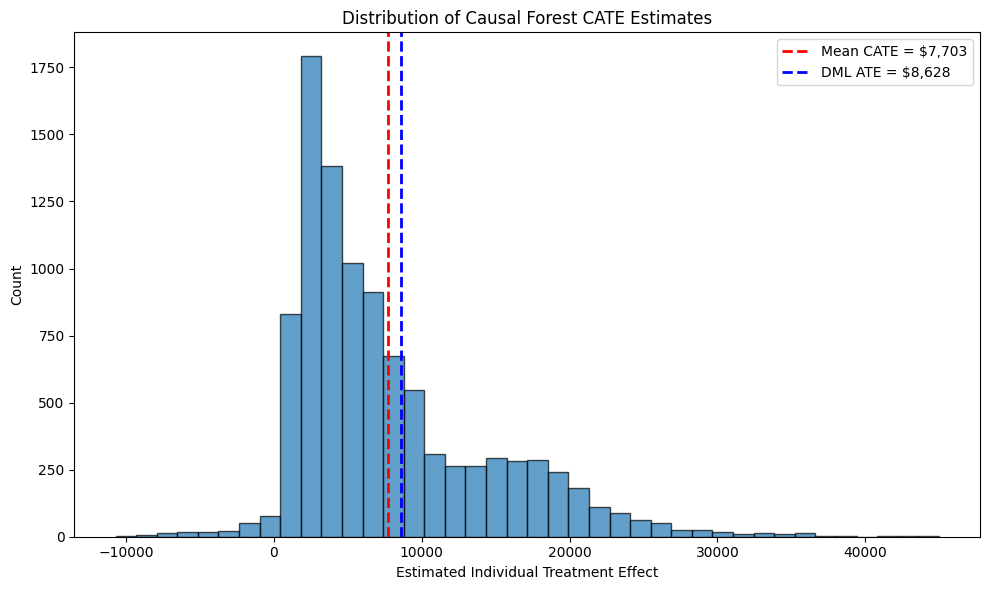

75th percentile threshold: $10,461
High-response group size: 2479
Lower-response group size: 7436
         High Response  Lower Response  Difference
age              43.77           40.16        3.61
inc           66478.87        27439.90    39038.97
educ             14.25           12.86        1.39
fsize             3.08            2.79        0.29
marr              0.84            0.53        0.32
twoearn           0.65            0.29        0.35
pira              0.46            0.17        0.29
hown              0.87            0.56        0.31


In [ ]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot a histogram of individual CATE estimates
# Include a vertical line at the mean CATE and the DML ATE for comparison

plt.figure(figsize=(10, 6))
plt.hist(cate_predictions, bins=40, edgecolor='black', alpha=0.7)

plt.axvline(np.mean(cate_predictions), color='red', linestyle='--', linewidth=2,
            label=f'Mean CATE = ${np.mean(cate_predictions):,.0f}')

plt.axvline(dml_plr.coef[0], color='blue', linestyle='--', linewidth=2,
            label=f'DML ATE = ${dml_plr.coef[0]:,.0f}')

plt.xlabel('Estimated Individual Treatment Effect')
plt.ylabel('Count')
plt.title('Distribution of Causal Forest CATE Estimates')
plt.legend()
plt.tight_layout()
plt.show()


# Step 2: Identify the "high-response" subgroup
# Define high-response as individuals with CATE above the 75th percentile
# Compare their characteristics to the rest of the sample

# Hint:
# threshold = np.percentile(cate_predictions, 75)
# high_resp = data[cate_predictions >= threshold]
# low_resp = data[cate_predictions < threshold]
# Compare mean income, age, education, etc.

threshold = np.percentile(cate_predictions, 75)

high_resp = data[cate_predictions >= threshold].copy()
low_resp = data[cate_predictions < threshold].copy()

print(f'75th percentile threshold: ${threshold:,.0f}')
print(f'High-response group size: {len(high_resp)}')
print(f'Lower-response group size: {len(low_resp)}')

comparison = pd.DataFrame({
    'High Response': high_resp[['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'pira', 'hown']].mean(),
    'Lower Response': low_resp[['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'pira', 'hown']].mean(),
    'Difference': (
        high_resp[['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'pira', 'hown']].mean()
        - low_resp[['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'pira', 'hown']].mean()
    )
})

print(comparison.round(2))


# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).
# If all subgroup means are identical, something went wrong.

Interpretation:

The cate distribution shows that the effect of 401(k) eligibility is not the same for everyone. The mean CATE (7,703) is close to the DML ATE (8,628), which shows the results are consistent. However, the wide spread and right tail indicate that some individuals benefit much more than others. The high-response group (top 25%) has much higher income, is older, and has more education compared to the rest of the sample. They are also more likely to be married, have two incomes, use IRAs, and own homes. This suggests that people with more financial resources and better saving habits benefit more from 401(k) eligibility.

                  mean      std  count
inc_quartile                          
Q1             3320.82  1924.97   2481
Q2             3834.65  2339.67   2477
Q3             6997.17  3691.06   2478
Q4            16658.80  6075.53   2479
Between-quartile difference in mean CATE: $13,338
Within-quartile standard deviations:
inc_quartile
Q1    1924.97
Q2    2339.67
Q3    3691.06
Q4    6075.53
Name: std, dtype: float64


<Figure size 900x600 with 0 Axes>

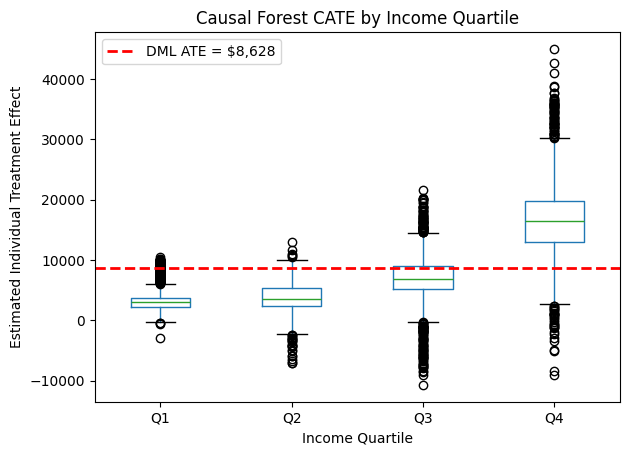


Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [ ]:
# -----------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# -----------------------------------------------------------

# The 3916 lab estimated CATE by income quartile using subgroup DML.
# Here we compare that coarse approach to the Causal Forest's
# continuous CATE predictions.

# Step 1: Compute mean Causal Forest CATE by income quartile
data['inc_quartile'] = pd.qcut(data['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# YOUR CODE: Group cate_predictions by income quartile
# For each quartile, compute mean CATE and std CATE

cate_df = data.copy()
cate_df['cate'] = cate_predictions

quartile_summary = cate_df.groupby('inc_quartile')['cate'].agg(['mean', 'std', 'count'])
print(quartile_summary.round(2))


# Step 2: Within each income quartile, how much variation remains?
# If the within-quartile std is large relative to the between-quartile
# difference, then quartile-level DML misses important heterogeneity.

between_range = quartile_summary['mean'].max() - quartile_summary['mean'].min()

print(f'Between-quartile difference in mean CATE: ${between_range:,.0f}')
print('Within-quartile standard deviations:')
print(quartile_summary['std'].round(2))


# Step 3: Visualize — overlay Causal Forest CATE distribution on
# the quartile-level DML bar chart
# Suggestion: Use a violin plot or box plot of CATE by quartile,
# showing the full distribution within each bin

plt.figure(figsize=(9, 6))
cate_df.boxplot(column='cate', by='inc_quartile', grid=False)
plt.axhline(dml_plr.coef[0], color='red', linestyle='--', linewidth=2,
            label=f'DML ATE = ${dml_plr.coef[0]:,.0f}')
plt.title('Causal Forest CATE by Income Quartile')
plt.suptitle('')
plt.xlabel('Income Quartile')
plt.ylabel('Estimated Individual Treatment Effect')
plt.legend()
plt.tight_layout()
plt.show()


print('\nKey question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')

Interpretation:

The mean cate increases across income quartiles, from about 3,321 in Q1 to 16,659 in Q4. This shows that higher-income households benefit more from 401(k) eligibility. However, there is still substantial variation within each quartile. The standard deviations are large, especially in higher-income groups, and the box plot shows a wide spread of treatment effects within each quartile. So, this means that while income explains some heterogeneity, subgroup DML by income quartile is still too coarse. The Causal Forest captures additional variation within each quartile that subgroup DML would miss.

---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

*Your answer*:*

I would use DML when my goal is to estimate one average treatment effect for the whole sample. The reason is that it is easier to interpret because it gives a single number, and I can also check robustness with sensitivity analysis. I would use Causal Forests when I want to understand how the treatment effect differs across individuals or groups. This is useful for targeting policies, but it needs more data and the results are harder to interpret.So, in general, DML is better for a clear and reliable average effect, while Causal Forests are better for exploring heterogeneity.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.